<a href="https://colab.research.google.com/github/mjcolebank/Colebank_REU_2026/blob/main/100k_Test/VanillaCNN_Standardized.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Convolutional Neural Networks in PyTorch

This notebook walks through the application of **convolutional neural networks (CNNs)** using PyTorch.

We will study two examples:

1. A **2D CNN for image classification** on the MNIST handwritten digit dataset.
2. A **1D CNN for time-series classification** on a synthetic signal dataset.

The goal is to mirror the ideas from the NumPy implementation, but now using PyTorch's built-in tools:

- `torch.Tensor`
- `torch.nn.Module`
- `torch.nn.Conv2d`
- `torch.nn.Conv1d`
- `torch.nn.ReLU`
- `torch.nn.MaxPool2d`
- `torch.nn.Linear`
- `torch.optim`
- automatic differentiation through `loss.backward()`

PyTorch handles the tedious backpropagation bookkeeping for us, but the mathematical structure is the same as the NumPy version.



## 1. What is a Convolutional Neural Network?

A fully connected neural network treats each input feature as separate. For images, this ignores spatial structure. A CNN instead uses **filters**, also called **kernels**, that slide across an input and detect local patterns.

For a 2D image, a convolutional layer learns filters that may detect edges, corners, curves, or other local image features.

For a 1D time series, a convolutional layer learns filters that may detect spikes, oscillations, trends, or short temporal patterns.

A typical CNN layer sequence is:

\[
\text{Input} \rightarrow \text{Convolution} \rightarrow \text{Activation} \rightarrow \text{Pooling} \rightarrow \text{Dense Layers} \rightarrow \text{Prediction}.
\]

In PyTorch, these operations are represented as neural network layers.



## 2. Imports and Reproducibility

We will use PyTorch for neural network layers and training, NumPy for data generation, and Matplotlib for visualization.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

import sympy
import sympy.core          # force submodule onto the namespace
import sympy.core.symbol
import torch               # now import torch

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, random_split

import importlib
sympy.core = importlib.import_module("sympy.core")
sympy.core.symbol = importlib.import_module("sympy.core.symbol")
print(hasattr(sympy, 'core'))

# Optional imports for MNIST.
# If torchvision is not installed, the synthetic time-series example will still run.

try:
    import torchvision
    import torchvision.transforms as transforms
    TORCHVISION_AVAILABLE = True
except ImportError:
    TORCHVISION_AVAILABLE = False

np.random.seed(42)
torch.manual_seed(42) #42

# Use a GPU if available. Otherwise, use CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


True
Using device: cpu



## 3. Helper Function: Training Loop

The same basic PyTorch training loop will be used for both the image example and the time-series example.

For each epoch:

1. Load a mini-batch.
2. Compute predictions.
3. Compute the loss.
4. Clear previous gradients.
5. Backpropagate using `loss.backward()`.
6. Update parameters using the optimizer.

For classification, we will use `nn.CrossEntropyLoss()`. This loss combines:

- a softmax operation, and
- the negative log-likelihood loss.

Therefore, our models should output raw scores, also called **logits**, not softmax probabilities.


In [2]:
def evaluate_classifier(model, data_loader, criterion):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            total_loss += loss.item() * X_batch.shape[0]
            predictions = torch.argmax(logits, dim=1)
            correct += (predictions == y_batch).sum().item()
            total += X_batch.shape[0]
    avg_loss = total_loss / total
    avg_acc = correct / total
    return avg_loss, avg_acc

def train_classifier(model, train_loader, test_loader=None, epochs=5, learning_rate=1e-3, verbose=True, enable_scheduler=False):
    # Train a PyTorch classifier using cross-entropy loss.
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=5e-2)

    scheduler = None
    if enable_scheduler:
        # Add a learning rate scheduler
        scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=20, T_mult=1, eta_min=1e-5
)

    history = {
        "train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": []
    }


    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        correct = 0
        total = 0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            batch_size = X_batch.shape[0]
            total_loss += loss.item() * batch_size
            predictions = torch.argmax(logits, dim=1)
            correct += (predictions == y_batch).sum().item()
            total += batch_size

        if scheduler:
            scheduler.step()

        train_loss = total_loss / total
        train_acc = correct / total
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)

        current_lr = optimizer.param_groups[0]['lr']

        if test_loader is not None:
            test_loss, test_acc = evaluate_classifier(model, test_loader, criterion)
            history["test_loss"].append(test_loss)
            history["test_acc"].append(test_acc)

            if verbose:
                print(
                    f"Epoch {epoch + 1}/{epochs}: "
                    f"lr = {current_lr:.6f}, " # Added learning rate
                    f"train loss = {train_loss:.4f}, train acc = {train_acc:.4f}, "
                    f"test loss = {test_loss:.4f}, test acc = {test_acc:.4f}"
                )

        else:
            if verbose:
                print(
                    f"Epoch {epoch + 1}/{epochs}: "
                    f"lr = {current_lr:.6f}, " # Added learning rate
                    f"train loss = {train_loss:.4f}, train acc = {train_acc:.4f}"
                )

    return history


## 4. Helper Function: Plot Training Curves


In [3]:

def plot_history(history, title="Training History"):
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(7, 4))
    plt.plot(epochs, history["train_loss"], label="train loss")
    if len(history["test_loss"]) > 0:
        plt.plot(epochs, history["test_loss"], label="test loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title + ": Loss")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(epochs, history["train_acc"], label="train accuracy")
    if len(history["test_acc"]) > 0:
        plt.plot(epochs, history["test_acc"], label="test accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(title + ": Accuracy")
    plt.grid(True)
    plt.legend()
    plt.show()


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import butter, filtfilt, find_peaks

In [5]:
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/REU ECG Analysis
!ls

Mounted at /content/drive
/content/drive/MyDrive/REU ECG Analysis
BCNN		    ECG_waveforms_1K.npy      outputs
ECG_metrics_1K.npy  EchoNext_EchoData_5K.csv  PaperFigures


In [6]:
ECG_data_1K = np.load('ECG_waveforms_1K.npy')
ECG_summary_1K = np.load('ECG_metrics_1K.npy')
Echo_5K = pd.read_csv('EchoNext_EchoData_5K.csv')

print(f"Actual shape of ECG_data_1K: {ECG_data_1K.shape}")
print(f"Number of elements in ECG_data_1K: {ECG_data_1K.size}")

# The original reshape was trying to achieve (1000, 2500, 12) which needs 30,000,000 elements.
# The error indicates that the loaded array has 1,966,064 elements, a significant mismatch.
# Please verify the correct dimensions for your 'ECG_waveforms_1K.npy' data.
# For now, I'm commenting out the problematic reshape and subsequent lines.

labels = Echo_5K['shd_moderate_or_greater_flag']
negative = labels==0
positive = labels==1
y_ts = np.array(labels[:1000])
X = ECG_data_1K[:1000]
X_ts = np.swapaxes(X, 1, 2)
print(X_ts.shape)
print(y_ts.shape)

Actual shape of ECG_data_1K: (1000, 2500, 12)
Number of elements in ECG_data_1K: 30000000
(1000, 12, 2500)
(1000,)



## 11. Visualize Example Time Series



## 12. Create PyTorch DataLoaders for Time Series


In [7]:

X_ts_tensor = torch.tensor(X_ts, dtype=torch.float32)
y_ts_tensor = torch.tensor(y_ts, dtype=torch.long)

ts_dataset = TensorDataset(X_ts_tensor, y_ts_tensor)

train_size = int(0.8 * len(ts_dataset))
test_size = len(ts_dataset) - train_size

ts_train_dataset, ts_test_dataset = random_split(
    ts_dataset,
    [train_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

ts_train_loader = DataLoader(ts_train_dataset, batch_size=32, shuffle=True) #change batch size
batch = next(iter(ts_train_loader))
print(batch[0].shape)

ts_test_loader = DataLoader(ts_test_dataset, batch_size=128, shuffle=False)

print("Time-series training samples:", len(ts_train_dataset))
print("Time-series test samples:", len(ts_test_dataset))


torch.Size([32, 12, 2500])
Time-series training samples: 800
Time-series test samples: 200



## 13. Define a 1D CNN for Time-Series Classification

This model uses:

1. `nn.Conv1d(1, 8, kernel_size=5, padding=2)`
2. `nn.ReLU()`
3. `nn.MaxPool1d(2)`
4. `nn.Conv1d(8, 16, kernel_size=5, padding=2)`
5. `nn.ReLU()`
6. `nn.MaxPool1d(2)`
7. Dense classifier layers

The original sequence length is 100.

After the first max pooling layer, the length becomes 50.

After the second max pooling layer, the length becomes 25.

The final convolutional feature tensor has shape:

\[
16 \times 25.
\]


In [8]:
import numpy as np
import matplotlib.pyplot as plt

def plot_history(history, title="Training History"):
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(7, 4))
    plt.plot(epochs, history["train_loss"], label="train loss")
    if len(history["test_loss"]) > 0:
        plt.plot(epochs, history["test_loss"], label="test loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title + ": Loss")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(epochs, history["train_acc"], label="train accuracy")
    if len(history["test_acc"]) > 0:
        plt.plot(epochs, history["test_acc"], label="test accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(title + ": Accuracy")
    plt.grid(True)
    plt.legend()
    plt.show()

In [9]:
class ImprovedSimplifiedTimeSeriesConvNet_V2(nn.Module):
    def __init__(self, sequence_length=2500, num_classes=2, in_channels=12):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv1d(in_channels, 16, kernel_size=7, padding=3),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.AdaptiveAvgPool1d(250),

            nn.Conv1d(16, 32, kernel_size=5, padding=2),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.6),
            nn.AdaptiveAvgPool1d(25),

            nn.Conv1d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.8),
            nn.AdaptiveAvgPool1d(1)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


# Instantiate the improved model
improved_ts_model_v2 = ImprovedSimplifiedTimeSeriesConvNet_V2(
    sequence_length=2500,
    num_classes=2,
    in_channels=12
)

print("Improved Simplified Model Architecture V2:")
print(improved_ts_model_v2)

Improved Simplified Model Architecture V2:
ImprovedSimplifiedTimeSeriesConvNet_V2(
  (features): Sequential(
    (0): Conv1d(12, 16, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): AdaptiveAvgPool1d(output_size=250)
    (5): Conv1d(16, 32, kernel_size=(5,), stride=(1,), padding=(2,))
    (6): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU()
    (8): Dropout(p=0.6, inplace=False)
    (9): AdaptiveAvgPool1d(output_size=25)
    (10): Conv1d(32, 32, kernel_size=(3,), stride=(1,), padding=(1,))
    (11): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): Dropout(p=0.8, inplace=False)
    (14): AdaptiveAvgPool1d(output_size=1)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=32, out_features

### 15.2 Train the Improved Simplified 1D CNN

Now, let's train this new, improved simplified model using the same training function.

### 15.3 Train the Improved Simplified 1D CNN V2

Now, let's train this new, improved simplified model (version 2) using the same training function.

Epoch 1/60: lr = 0.000099, train loss = 0.6929, train acc = 0.5363, test loss = 0.6884, test acc = 0.5000
Epoch 2/60: lr = 0.000098, train loss = 0.6725, train acc = 0.5400, test loss = 0.6601, test acc = 0.5000
Epoch 3/60: lr = 0.000095, train loss = 0.6606, train acc = 0.5600, test loss = 0.6446, test acc = 0.5450
Epoch 4/60: lr = 0.000091, train loss = 0.6584, train acc = 0.5587, test loss = 0.6344, test acc = 0.6500
Epoch 5/60: lr = 0.000087, train loss = 0.6427, train acc = 0.5775, test loss = 0.6247, test acc = 0.6900
Epoch 6/60: lr = 0.000081, train loss = 0.6489, train acc = 0.6125, test loss = 0.6175, test acc = 0.7300
Epoch 7/60: lr = 0.000075, train loss = 0.6473, train acc = 0.5975, test loss = 0.6121, test acc = 0.7200
Epoch 8/60: lr = 0.000069, train loss = 0.6377, train acc = 0.6175, test loss = 0.6047, test acc = 0.7300
Epoch 9/60: lr = 0.000062, train loss = 0.6301, train acc = 0.6212, test loss = 0.6038, test acc = 0.7400
Epoch 10/60: lr = 0.000055, train loss = 0.634

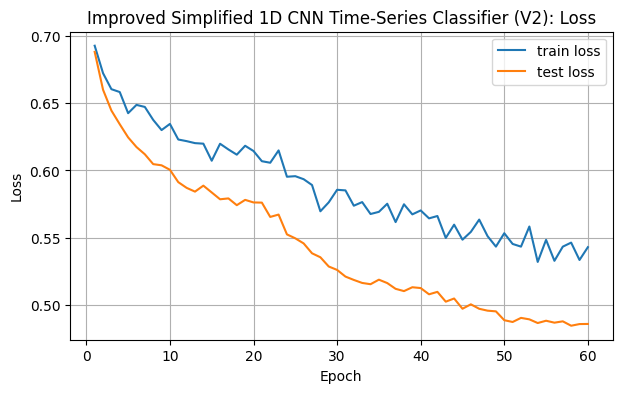

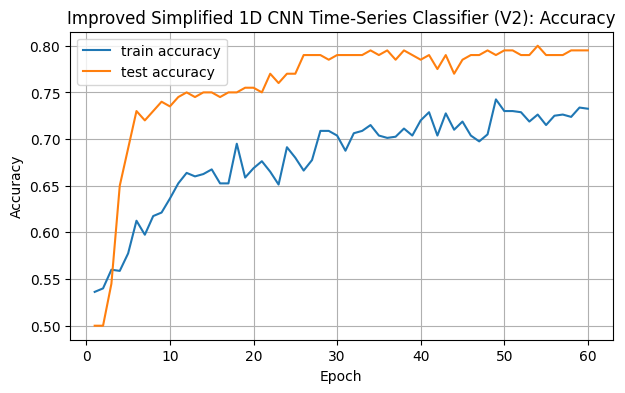

In [10]:
improved_ts_model_v2 = ImprovedSimplifiedTimeSeriesConvNet_V2(sequence_length=2500, num_classes=2);
improved_simplified_ts_history_v2 = train_classifier(
    improved_ts_model_v2,
    ts_train_loader,
    ts_test_loader,
    epochs=60,
    learning_rate=1e-4,
    verbose=True,
    enable_scheduler=True
)

plot_history(improved_simplified_ts_history_v2, title="Improved Simplified 1D CNN Time-Series Classifier (V2)")


## 15. Inspect Time-Series Predictions


## 1. Setup

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    log_loss,
    brier_score_loss,
    roc_curve,
    precision_recall_curve,
    auc,
)

## 2. Prediction objects used by the metrics

In [12]:
def as_numpy(x):
    """Convert torch tensors or array-like objects to NumPy arrays."""
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)


def probs_to_predictions(probs, threshold=0.5):
    """
    Convert probabilities to hard class predictions.

    Args:
        probs: Either shape [N] containing P(class 1), or shape [N, 2]
               containing [P(class 0), P(class 1)].
        threshold: Positive-class threshold used if probs has shape [N].

    Returns:
        y_pred: shape [N]
    """
    probs = as_numpy(probs)

    if probs.ndim == 1:
        return (probs >= threshold).astype(int)

    if probs.ndim == 2:
        return np.argmax(probs, axis=1).astype(int)

    raise ValueError("probs must have shape [N] or [N, C].")


def positive_class_probability(probs):
    """
    Extract P(class 1) from either shape [N] or shape [N, 2].
    """
    probs = as_numpy(probs)

    if probs.ndim == 1:
        return probs

    if probs.ndim == 2 and probs.shape[1] == 2:
        return probs[:, 1]

    raise ValueError("For binary metrics, probs must have shape [N] or [N, 2].")

## 3. Collecting predictions from a standard neural network

In [13]:
@torch.no_grad()
def collect_predictions_standard_nn(model, data_loader, device):
    """
    Collect labels and probabilities from a standard deterministic neural network.

    Args:
        model: PyTorch classifier returning logits of shape [batch_size, 2].
        data_loader: DataLoader yielding (x, y).
        device: torch device.

    Returns:
        y_true: shape [N]
        probs: shape [N, 2]
        y_pred: shape [N]
    """
    model.eval()

    all_y = []
    all_probs = []

    for x, y in data_loader:
        x = x.to(device)
        y = y.to(device)

        logits = model(x)
        probs = F.softmax(logits, dim=-1)

        all_y.append(y.detach().cpu())
        all_probs.append(probs.detach().cpu())

    y_true = torch.cat(all_y, dim=0).numpy()
    probs = torch.cat(all_probs, dim=0).numpy()
    y_pred = probs.argmax(axis=1)

    return y_true, probs, y_pred

## 5. Confusion matrix quantities

In [14]:
def confusion_counts(y_true, y_pred):
    """
    Return TN, FP, FN, TP for binary labels 0 and 1.
    """
    y_true = as_numpy(y_true).astype(int)
    y_pred = as_numpy(y_pred).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return tn, fp, fn, tp

## 6. Accuracy

In [15]:
def compute_accuracy(y_true, y_pred):
    y_true = as_numpy(y_true)
    y_pred = as_numpy(y_pred)
    return np.mean(y_true == y_pred)

## 7. Sensitivity and specificity

In [16]:
def compute_sensitivity_specificity(y_true, y_pred):
    tn, fp, fn, tp = confusion_counts(y_true, y_pred)

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan

    return sensitivity, specificity

## 8. Balanced accuracy

In [17]:
def compute_balanced_accuracy(y_true, y_pred):
    sensitivity, specificity = compute_sensitivity_specificity(y_true, y_pred)
    return 0.5 * (sensitivity + specificity)

## 9. AUROC

In [18]:
def compute_auroc(y_true, probs):
    y_true = as_numpy(y_true).astype(int)
    p1 = positive_class_probability(probs)

    if len(np.unique(y_true)) < 2:
        return np.nan

    return roc_auc_score(y_true, p1)


def plot_roc_curve(y_true, probs):
    y_true = as_numpy(y_true).astype(int)
    p1 = positive_class_probability(probs)

    fpr, tpr, thresholds = roc_curve(y_true, p1)
    score = roc_auc_score(y_true, p1)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUROC = {score:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
    plt.xlabel("False positive rate")
    plt.ylabel("True positive rate / sensitivity")
    plt.title("ROC curve")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

## 10. AUPRC

In [19]:
def compute_auprc(y_true, probs):
    y_true = as_numpy(y_true).astype(int)
    p1 = positive_class_probability(probs)

    if len(np.unique(y_true)) < 2:
        return np.nan

    return average_precision_score(y_true, p1)


def plot_precision_recall_curve(y_true, probs):
    y_true = as_numpy(y_true).astype(int)
    p1 = positive_class_probability(probs)

    precision, recall, thresholds = precision_recall_curve(y_true, p1)
    score = average_precision_score(y_true, p1)
    prevalence = np.mean(y_true == 1)

    plt.figure(figsize=(6, 5))
    plt.plot(recall, precision, label=f"AUPRC = {score:.3f}")
    plt.hlines(prevalence, 0, 1, linestyle="--", label=f"Baseline = {prevalence:.3f}")
    plt.xlabel("Recall / sensitivity")
    plt.ylabel("Precision")
    plt.title("Precision-recall curve")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

## 11. Negative log likelihood

In [20]:
def compute_negative_log_likelihood(y_true, probs, eps=1e-12):
    y_true = as_numpy(y_true).astype(int)
    probs = as_numpy(probs)

    if probs.ndim == 1:
        p1 = np.clip(probs, eps, 1.0 - eps)
        return -np.mean(y_true * np.log(p1) + (1 - y_true) * np.log(1 - p1))

    if probs.ndim == 2:
        probs = np.clip(probs, eps, 1.0)
        probs = probs / probs.sum(axis=1, keepdims=True)
        return log_loss(y_true, probs, labels=[0, 1])

    raise ValueError("probs must have shape [N] or [N, 2].")

## 12. Brier score

In [21]:
def compute_brier_score(y_true, probs):
    y_true = as_numpy(y_true).astype(int)
    p1 = positive_class_probability(probs)
    return np.mean((p1 - y_true) ** 2)

## 13. Expected calibration error

In [22]:
def compute_expected_calibration_error(y_true, probs, n_bins=10):
    """
    Confidence-based ECE for binary or multiclass probabilities.

    Args:
        y_true: shape [N]
        probs: shape [N, C] or shape [N] for binary P(class 1)
        n_bins: number of confidence bins

    Returns:
        ece: scalar
    """
    y_true = as_numpy(y_true).astype(int)
    probs = as_numpy(probs)

    if probs.ndim == 1:
        probs = np.column_stack([1.0 - probs, probs])

    y_pred = probs.argmax(axis=1)
    confidence = probs.max(axis=1)
    correct = (y_pred == y_true).astype(float)

    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0

    for m in range(n_bins):
        lo = bin_edges[m]
        hi = bin_edges[m + 1]

        if m == 0:
            in_bin = (confidence >= lo) & (confidence <= hi)
        else:
            in_bin = (confidence > lo) & (confidence <= hi)

        prop = np.mean(in_bin)

        if prop > 0:
            acc_bin = np.mean(correct[in_bin])
            conf_bin = np.mean(confidence[in_bin])
            ece += prop * abs(acc_bin - conf_bin)

    return ece


def calibration_table(y_true, probs, n_bins=10):
    """
    Return bin-level calibration information.
    """
    y_true = as_numpy(y_true).astype(int)
    probs = as_numpy(probs)

    if probs.ndim == 1:
        probs = np.column_stack([1.0 - probs, probs])

    y_pred = probs.argmax(axis=1)
    confidence = probs.max(axis=1)
    correct = (y_pred == y_true).astype(float)

    rows = []
    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)

    for m in range(n_bins):
        lo = bin_edges[m]
        hi = bin_edges[m + 1]

        if m == 0:
            in_bin = (confidence >= lo) & (confidence <= hi)
        else:
            in_bin = (confidence > lo) & (confidence <= hi)

        n_bin = int(np.sum(in_bin))

        if n_bin > 0:
            rows.append({
                "bin": m + 1,
                "confidence_lower": lo,
                "confidence_upper": hi,
                "n": n_bin,
                "mean_confidence": float(np.mean(confidence[in_bin])),
                "empirical_accuracy": float(np.mean(correct[in_bin])),
                "abs_gap": float(abs(np.mean(correct[in_bin]) - np.mean(confidence[in_bin]))),
            })
        else:
            rows.append({
                "bin": m + 1,
                "confidence_lower": lo,
                "confidence_upper": hi,
                "n": 0,
                "mean_confidence": np.nan,
                "empirical_accuracy": np.nan,
                "abs_gap": np.nan,
            })

    return pd.DataFrame(rows)


def plot_calibration_curve(y_true, probs, n_bins=10):
    table = calibration_table(y_true, probs, n_bins=n_bins)
    table_nonempty = table.dropna(subset=["mean_confidence", "empirical_accuracy"])

    plt.figure(figsize=(6, 5))
    plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
    plt.scatter(
        table_nonempty["mean_confidence"],
        table_nonempty["empirical_accuracy"],
        s=50,
        label="Observed bins",
    )
    plt.xlabel("Mean confidence")
    plt.ylabel("Empirical accuracy")
    plt.title("Calibration curve")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

## 14. Negative ELBO

In [23]:
def estimate_negative_elbo_per_example_pyro(model, guide, data_loader, device, dataset_size=None):
    """
    Estimate negative ELBO per example for a Pyro Bayesian neural network.

    Args:
        model: Pyro model with forward(x, y=None, dataset_size=None).
        guide: Pyro guide.
        data_loader: DataLoader yielding (x, y).
        device: torch device.
        dataset_size: Optional size used for minibatch scaling. If None, each batch
                      uses its own batch size, which is often appropriate for a
                      held-out evaluation estimate.

    Returns:
        negative_elbo_per_example: scalar float
    """
    try:
        import pyro
        from pyro.infer import Trace_ELBO
    except ImportError as exc:
        raise ImportError("This function requires Pyro. Install pyro-ppl first.") from exc

    model.eval()
    elbo = Trace_ELBO()

    total_loss = 0.0
    total_examples = 0

    for x, y in data_loader:
        x = x.to(device)
        y = y.to(device)
        batch_size = x.shape[0]
        ds = dataset_size if dataset_size is not None else batch_size

        loss = elbo.differentiable_loss(model, guide, x, y, ds)

        total_loss += float(loss.detach().cpu())
        total_examples += batch_size

    return total_loss / max(total_examples, 1)


def estimate_cross_entropy_per_example_standard_nn(model, data_loader, device):
    """
    Estimate cross-entropy/NLL per example for a standard neural network.
    This is the standard deterministic analogue of the likelihood part of ELBO.
    """
    model.eval()

    total_loss = 0.0
    total_examples = 0

    with torch.no_grad():
        for x, y in data_loader:
            x = x.to(device)
            y = y.to(device)
            logits = model(x)
            loss = F.cross_entropy(logits, y, reduction="sum")
            total_loss += float(loss.detach().cpu())
            total_examples += x.shape[0]

    return total_loss / max(total_examples, 1)

## 15. One function to calculate all non-ELBO metrics

In [24]:
def calculate_binary_classification_metrics(y_true, probs, threshold=0.5, n_bins=10):
    """
    Calculate binary classification metrics from labels and probabilities.

    Args:
        y_true: shape [N], labels 0/1.
        probs: shape [N] containing P(class 1), or shape [N, 2].
        threshold: threshold for P(class 1), used only if probs has shape [N].
        n_bins: number of bins for ECE.

    Returns:
        metrics: dictionary
    """
    y_true = as_numpy(y_true).astype(int)
    probs = as_numpy(probs)

    if probs.ndim == 1:
        y_pred = probs_to_predictions(probs, threshold=threshold)
        p1 = probs
        probs_2d = np.column_stack([1.0 - p1, p1])
    else:
        y_pred = probs.argmax(axis=1)
        p1 = probs[:, 1]
        probs_2d = probs

    tn, fp, fn, tp = confusion_counts(y_true, y_pred)
    sensitivity, specificity = compute_sensitivity_specificity(y_true, y_pred)

    metrics = {
        "accuracy": compute_accuracy(y_true, y_pred),
        "balanced_accuracy": compute_balanced_accuracy(y_true, y_pred),
        "auroc": compute_auroc(y_true, probs_2d),
        "auprc": compute_auprc(y_true, probs_2d),
        "sensitivity": sensitivity,
        "specificity": specificity,
        "negative_log_likelihood": compute_negative_log_likelihood(y_true, probs_2d),
        "brier_score": compute_brier_score(y_true, probs_2d),
        "expected_calibration_error": compute_expected_calibration_error(y_true, probs_2d, n_bins=n_bins),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
        "positive_prevalence": float(np.mean(y_true == 1)),
    }

    return metrics

## 16. Wrapper for a standard neural network classifier (use later)

In [25]:
def evaluate_standard_nn_classifier(model, data_loader, device, n_bins=10):
    y_true, probs, y_pred = collect_predictions_standard_nn(
        model=model,
        data_loader=data_loader,
        device=device,
    )

    metrics = calculate_binary_classification_metrics(
        y_true=y_true,
        probs=probs,
        n_bins=n_bins,
    )

    metrics["cross_entropy_per_example"] = estimate_cross_entropy_per_example_standard_nn(
        model=model,
        data_loader=data_loader,
        device=device,
    )

    return metrics, y_true, probs, y_pred

## 18. Demonstration with synthetic predictions

In [28]:
# Ensure all models are moved to the device for evaluation.

improved_ts_model_v2.to(device)


improved_simplified_ts_metrics_v2, improved_simplified_ts_y_true_v2, improved_simplified_ts_probs_v2, improved_simplified_ts_y_pred_v2 = evaluate_standard_nn_classifier(
    model=improved_ts_model_v2,
    data_loader=ts_test_loader,
    device=device,
    n_bins=10,
)

comparison_df = pd.DataFrame(
    [
        improved_simplified_ts_metrics_v2
    ],
    index=
    [
        "Improved Simplified (V2 - 3 Layers, AdaptiveAvgPool, BatchNorm, Dropout 0.5-0.8)"
    ]
).T

display(comparison_df)
print(improved_simplified_ts_y_true_v2)
print(improved_simplified_ts_probs_v2)


,"Improved Simplified (V2 - 3 Layers, AdaptiveAvgPool, BatchNorm, Dropout 0.5-0.8)"
accuracy,0.795000
balanced_accuracy,0.795000
auroc,0.870100
auprc,0.861014
sensitivity,0.740000
specificity,0.850000
negative_log_likelihood,0.485662
brier_score,0.157270
expected_calibration_error,0.097295
tn,85.000000


[0 1 1 1 0 1 0 1 1 0 1 1 0 1 1 0 0 1 0 0 0 1 1 1 0 0 0 0 0 1 0 1 1 0 0 0 0
 0 0 1 1 0 1 0 1 0 0 0 1 1 0 0 1 1 1 0 1 0 0 0 1 1 0 0 0 0 0 0 0 0 0 1 1 0
 0 1 0 0 1 1 1 0 0 1 0 1 1 1 1 1 0 0 1 1 0 0 0 1 0 0 0 1 0 0 0 1 0 1 0 0 0
 1 1 1 1 1 1 0 0 1 1 0 0 1 0 1 1 1 1 1 0 0 0 0 1 1 1 1 1 0 1 1 0 0 0 1 0 0
 1 0 1 1 1 1 1 0 1 0 1 1 1 0 0 0 0 0 1 0 1 0 0 0 0 1 1 1 1 0 0 1 1 0 0 1 1
 0 1 0 1 1 1 1 0 1 1 1 1 1 1 0]
[[6.69638455e-01 3.30361515e-01]
 [6.66157782e-01 3.33842248e-01]
 [4.72690076e-01 5.27309954e-01]
 [1.86503783e-01 8.13496232e-01]
 [6.45849466e-01 3.54150504e-01]
 [2.49232113e-01 7.50767887e-01]
 [4.70502943e-01 5.29497087e-01]
 [1.37305884e-02 9.86269414e-01]
 [4.53685313e-01 5.46314657e-01]
 [6.99606776e-01 3.00393194e-01]
 [4.93000865e-01 5.06999135e-01]
 [4.15139019e-01 5.84861040e-01]
 [8.30726683e-01 1.69273347e-01]
 [2.88415551e-01 7.11584389e-01]
 [2.27042437e-01 7.72957504e-01]
 [7.06107259e-01 2.93892771e-01]
 [6.60077333e-01 3.39922667e-01]
 [5.72237432e-01 4.27762598e-01]

Confusion matrix [[TN, FP], [FN, TP]]:
[[85 15]
 [26 74]]


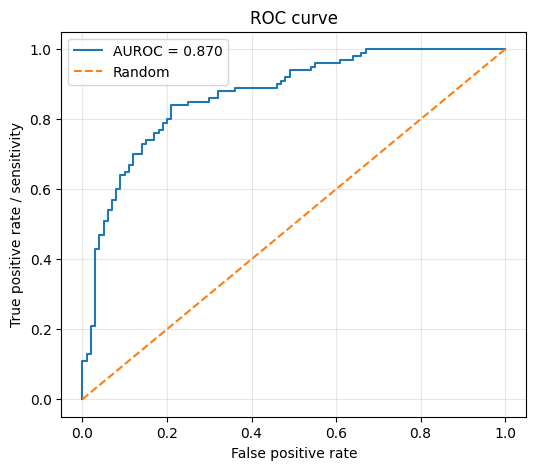

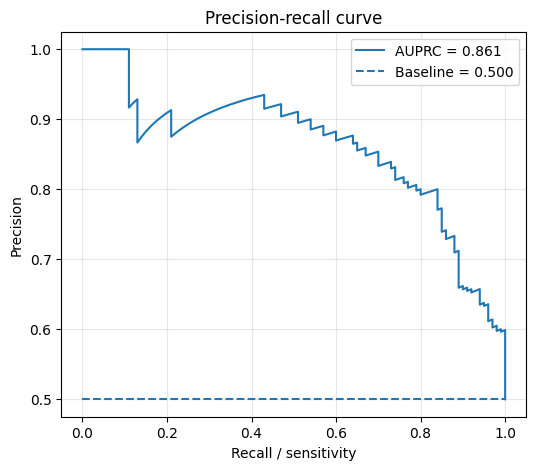

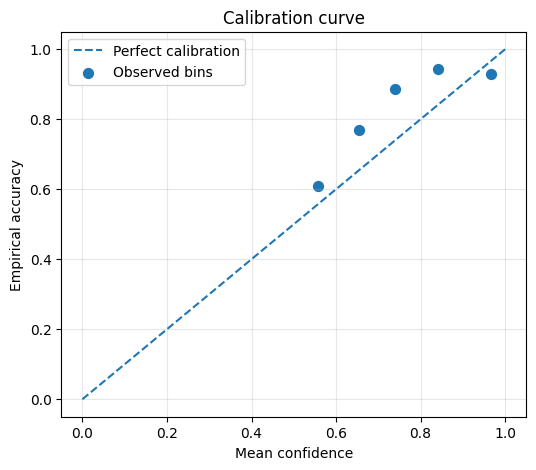

,bin,confidence_lower,confidence_upper,n,mean_confidence,empirical_accuracy,abs_gap
0,1,0.0,0.1,0,NaN,NaN,NaN
1,2,0.1,0.2,0,NaN,NaN,NaN
2,3,0.2,0.3,0,NaN,NaN,NaN
3,4,0.3,0.4,0,NaN,NaN,NaN
4,5,0.4,0.5,0,NaN,NaN,NaN
5,6,0.5,0.6,51,0.558326,0.607843,0.049518
6,7,0.6,0.7,56,0.654240,0.767857,0.113617
7,8,0.7,0.8,44,0.739346,0.886364,0.147018
8,9,0.8,0.9,35,0.840610,0.942857,0.102247
9,10,0.9,1.0,14,0.965973,0.928571,0.037401


In [31]:
print("Confusion matrix [[TN, FP], [FN, TP]]:")
print(confusion_matrix(improved_simplified_ts_y_true_v2, improved_simplified_ts_y_pred_v2, labels=[0, 1]))

plot_roc_curve(improved_simplified_ts_y_true_v2, improved_simplified_ts_probs_v2)
plot_precision_recall_curve(improved_simplified_ts_y_true_v2, improved_simplified_ts_probs_v2)
plot_calibration_curve(improved_simplified_ts_y_true_v2, improved_simplified_ts_probs_v2, n_bins=10)
calibration_table(improved_simplified_ts_y_true_v2, improved_simplified_ts_probs_v2, n_bins=10)